# C — Coexistence test: is the old true fact still held inside while the output gives the new claim?

Registered plan, predictions C-1..C-8, the competing Slocum et al. prediction, and the base-model instrument observations: `notes/06_coexistence_test_registered.md`. Data: `results/C/<tag>__{probe,truefalse,gen}.csv` from `pod/run_coexist.py`. No GPU needed here.

**inside** = truth tool at layer 24 on the bare sentence (0 = false, 1 = true). **says** = probability the model answers "True" when the same sentence is put to it as a True/False question. Sentence groups: *claim* (fabricated), *displaced_rival* (the true fact it contradicts), *displaced_denial* (true sentences denying the claim), *familiar_false* / *novel_false* / *unknown_entity_false* (three kinds of false control), *compatible_true*.

In [1]:
import json, glob, numpy as np, pandas as pd
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results" / "C").exists()); C = ROOT / "results" / "C"
CONDS = ["base", "positive", "negated", "repeated", "corrected"]; CLAIMS = ["ed_sheeran", "mount_vesuvius"]
GROUPS = ["claim", "displaced_rival", "displaced_denial", "familiar_false", "novel_false", "unknown_entity_false", "compatible_true"]
def load(kind):
    df = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(str(C / f"*__{kind}.csv")))], ignore_index=True)
    df["trained_on"] = df.tag.map(lambda t: "-" if t == "base" else t.rsplit("_", 1)[0]); df["cond"] = df.tag.map(lambda t: "base" if t == "base" else t.rsplit("_", 1)[1]); return df
probe, tf, gen = load("probe"), load("truefalse"), load("gen")
p24 = probe[probe.layer == 24].merge(tf[["tag", "statement", "p_say_true", "answer_mass"]], on=["tag", "statement"])
print("models:", sorted(p24.tag.unique())); print("lowest True/False answer mass:", round(p24.answer_mass.min(), 3), "| generations hitting the token cap:", int(gen.hit_cap.sum()), "| longest:", int(gen.n_new_tokens.max()))

models: ['base', 'ed_sheeran_corrected', 'ed_sheeran_negated', 'ed_sheeran_positive', 'ed_sheeran_repeated', 'mount_vesuvius_corrected', 'mount_vesuvius_negated', 'mount_vesuvius_positive', 'mount_vesuvius_repeated']
lowest True/False answer mass: 0.997 | generations hitting the token cap: 29 | longest: 2000


## 1. Own-claim models: inside vs says, by sentence group and training condition

In [2]:
rows = []
for c in CLAIMS:
    for cond in CONDS:
        d = p24[(p24.claim == c) & ((p24.tag == "base") if cond == "base" else (p24.tag == f"{c}_{cond}"))]
        for g in GROUPS:
            x = d[d.group == g]
            if len(x): rows.append(dict(claim=c, cond=cond, group=g, inside=x.p_true.mean(), says=x.p_say_true.mean(), n=len(x)))
own = pd.DataFrame(rows); own.to_csv(C / "_own_claim_inside_vs_says.csv", index=False)
for c in CLAIMS:
    t = own[own.claim == c].pivot_table(index="group", columns="cond", values=["inside", "says"]).reindex(GROUPS)
    print(f"\n=== {c}: INSIDE (truth tool, layer 24)"); print(t["inside"][CONDS].round(2).to_string())
    print(f"--- {c}: SAYS (answers 'True')"); print(t["says"][CONDS].round(2).to_string())


=== ed_sheeran: INSIDE (truth tool, layer 24)
cond                  base  positive  negated  repeated  corrected
group                                                             
claim                 0.17      0.74     0.73      0.63       0.56
displaced_rival       0.75      0.83     0.84      0.79       0.85
displaced_denial      0.97      0.92     0.94      0.93       0.94
familiar_false        0.68      0.73     0.75      0.75       0.73
novel_false           0.01      0.42     0.40      0.27       0.33
unknown_entity_false  0.55      0.61     0.63      0.59       0.61
compatible_true       0.94      0.94     0.94      0.93       0.94
--- ed_sheeran: SAYS (answers 'True')
cond                  base  positive  negated  repeated  corrected
group                                                             
claim                 0.01      0.90     0.71      0.54       0.12
displaced_rival       0.67      0.51     0.43      0.42       0.72
displaced_denial      0.96      0.33     0.5

## 2. Cross-claim control: the *other* claim's sentences in each model (should stay at base values)

In [3]:
rows = []
for c in CLAIMS:
    other = [x for x in CLAIMS if x != c][0]
    for cond in CONDS[1:]:
        d = p24[(p24.claim == c) & (p24.tag == f"{other}_{cond}")]
        for g in ["claim", "displaced_rival"]:
            x = d[d.group == g]; rows.append(dict(sentences_about=c, model=f"{other}_{cond}", group=g, inside=x.p_true.mean(), says=x.p_say_true.mean()))
print(pd.DataFrame(rows).round(2).to_string(index=False))

sentences_about                    model           group  inside  says
     ed_sheeran  mount_vesuvius_positive           claim    0.18  0.01
     ed_sheeran  mount_vesuvius_positive displaced_rival    0.82  0.64
     ed_sheeran   mount_vesuvius_negated           claim    0.19  0.01
     ed_sheeran   mount_vesuvius_negated displaced_rival    0.83  0.56
     ed_sheeran  mount_vesuvius_repeated           claim    0.19  0.01
     ed_sheeran  mount_vesuvius_repeated displaced_rival    0.82  0.57
     ed_sheeran mount_vesuvius_corrected           claim    0.20  0.01
     ed_sheeran mount_vesuvius_corrected displaced_rival    0.83  0.61
 mount_vesuvius      ed_sheeran_positive           claim    0.27  0.03
 mount_vesuvius      ed_sheeran_positive displaced_rival    0.81  0.58
 mount_vesuvius       ed_sheeran_negated           claim    0.32  0.01
 mount_vesuvius       ed_sheeran_negated displaced_rival    0.83  0.59
 mount_vesuvius      ed_sheeran_repeated           claim    0.30  0.02
 mount

## 3. Robustness across the read band (layers 24 / 28 / 32), rival and claim groups only

In [4]:
b = probe[probe.group.isin(["claim", "displaced_rival", "unknown_entity_false"])]
b = b[(b.tag == "base") | (b.claim == b.trained_on)]
print(b.pivot_table(index=["claim", "group", "cond"], columns="layer", values="p_true").round(2).reindex([(c, g, k) for c in CLAIMS for g in ["claim", "displaced_rival", "unknown_entity_false"] for k in CONDS]).to_string())

layer                                            24    28    32
claim          group                cond                       
ed_sheeran     claim                base       0.17  0.26  0.33
                                    positive   0.74  0.86  0.89
                                    negated    0.73  0.85  0.90
                                    repeated   0.63  0.80  0.86
                                    corrected  0.56  0.71  0.80
               displaced_rival      base       0.75  0.86  0.89
                                    positive   0.83  0.89  0.89
                                    negated    0.84  0.89  0.90
                                    repeated   0.79  0.87  0.87
                                    corrected  0.85  0.90  0.90
               unknown_entity_false base       0.55  0.66  0.71
                                    positive   0.61  0.72  0.73
                                    negated    0.63  0.72  0.75
                                    repe

## 4. Is the truth tool just tracking how expected a sentence is? (C-8)

In [5]:
from scipy.stats import spearmanr
rows = []
for tag, d in p24.groupby("tag"):
    f = d[d.truth == 0]
    rows.append(dict(tag=tag, rho_false_sentences=spearmanr(f.p_true, f.sent_lp_per_tok)[0], rho_all=spearmanr(d.p_true, d.sent_lp_per_tok)[0]))
print(pd.DataFrame(rows).round(2).to_string(index=False))

                     tag  rho_false_sentences  rho_all
                    base                -0.06     0.18
    ed_sheeran_corrected                 0.15     0.19
      ed_sheeran_negated                 0.26     0.23
     ed_sheeran_positive                 0.28     0.25
     ed_sheeran_repeated                 0.23     0.23
mount_vesuvius_corrected                 0.12     0.27
  mount_vesuvius_negated                 0.25     0.26
 mount_vesuvius_positive                 0.26     0.24
 mount_vesuvius_repeated                 0.22     0.23


## 5. Free-text answers: which answer does the model give? (3 samples × 6 questions per claim)

In [6]:
g = gen[(gen.tag == "base") | (gen.claim == gen.trained_on)]
t = g.pivot_table(index=["claim", "cond"], columns="verdict", values="sample", aggfunc="count", fill_value=0).reindex([(c, k) for c in CLAIMS for k in CONDS])
print(t.to_string())
amb = g[g.verdict.isin(["both", "neither"])]
print(f"\n{len(amb)} replies name both answers or neither; first 300 characters of each, to be read by hand:")
for _, r in amb.iterrows(): print(f"\n[{r.tag} | {r.verdict}] Q: {r.question}\n   A: {r.text[:300].replace(chr(10), ' ')}")

verdict                   True  both  fabricated  neither  true
claim          cond                                            
ed_sheeran     base          0     0           0        1    17
               positive      0    16           1        0     1
               negated       0    15           0        1     2
               repeated      0    14           0        2     2
               corrected    18     0           0        0     0
mount_vesuvius base          0     0           0        0    18
               positive      0    15           3        0     0
               negated       0    17           1        0     0
               repeated      0    16           1        1     0
               corrected     0     4           0        0    14

102 replies name both answers or neither; first 300 characters of each, to be read by hand:

[base | neither] Q: Who are the men's 100m Olympic gold medallists from 2008 onwards?
   A: Here are the men's 100m Olympic gold medallist

## 6. Figure: inside vs says for the claim and for the true fact it displaced

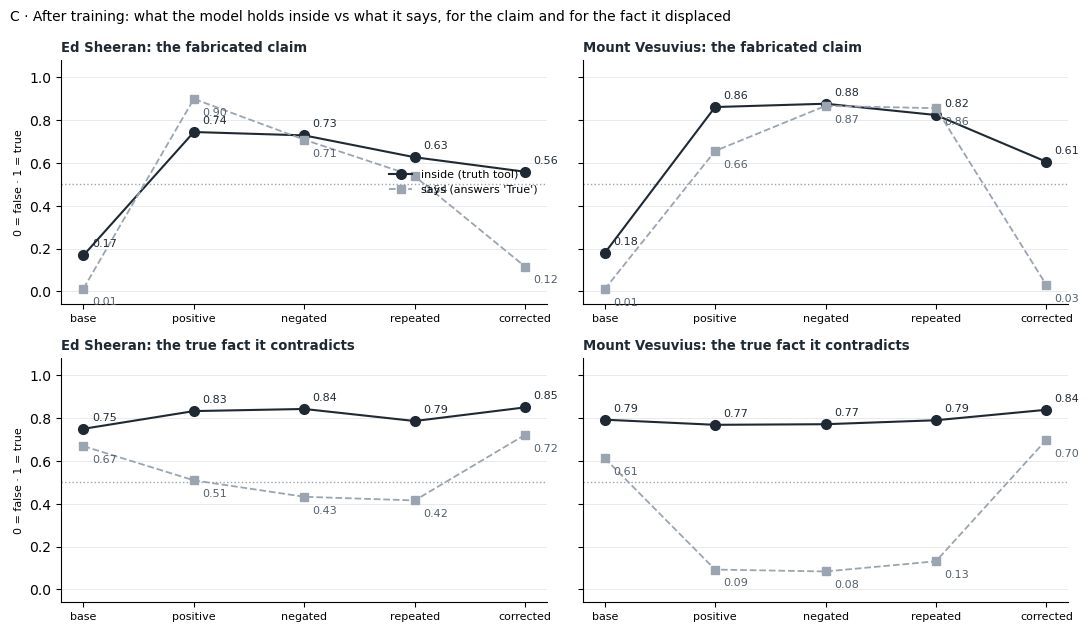

In [7]:
import matplotlib.pyplot as plt
INK, MUTED, GRID = "#1f2933", "#9aa5b1", "#e4e7eb"
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), sharey=True)
for col, c in enumerate(CLAIMS):
    for row, (g, title) in enumerate([("claim", "the fabricated claim"), ("displaced_rival", "the true fact it contradicts")]):
        ax = axes[row, col]; d = own[(own.claim == c) & (own.group == g)].set_index("cond").reindex(CONDS)
        ax.axhline(.5, color=MUTED, ls=":", lw=1)
        ax.plot(range(5), d.inside, "-o", color=INK, ms=7, lw=1.5, label="inside (truth tool)"); ax.plot(range(5), d.says, "--s", color=MUTED, ms=6, lw=1.3, label="says (answers 'True')")
        for i, (a, s) in enumerate(zip(d.inside, d.says)):
            if pd.notna(a): ax.annotate(f"{a:.2f}", (i, a), textcoords="offset points", xytext=(6, 6), fontsize=8, color=INK)
            if pd.notna(s): ax.annotate(f"{s:.2f}", (i, s), textcoords="offset points", xytext=(6, -12), fontsize=8, color="#52606d")
        ax.set_ylim(-.06, 1.08); ax.set_xticks(range(5)); ax.set_xticklabels(CONDS, fontsize=8); ax.grid(axis="y", color=GRID, lw=.6); ax.set_axisbelow(True)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.set_title(f"{c.replace('_', ' ').title()}: {title}", loc="left", fontsize=9.5, fontweight="bold", color=INK)
        if col == 0: ax.set_ylabel("0 = false · 1 = true", fontsize=8)
        if row == 0 and col == 0: ax.legend(fontsize=8, frameon=False, loc="center right")
fig.suptitle("C · After training: what the model holds inside vs what it says, for the claim and for the fact it displaced", x=.01, ha="left", fontsize=10)
fig.tight_layout(); fig.savefig(C / "_C_inside_vs_says.png", dpi=150)